In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
borrowers = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/borrowers.csv")
accounts = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/accounts.csv")
agents = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/agents.csv")
agent_sessions = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/agent_sessions.csv")

campaigns = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/campaigns.csv")
daily_targeting = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/daily_targeting.csv")

calls = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/calls.csv")
call_attempts = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/call_attempts.csv")
call_dispositions = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/call_dispositions.csv")

whatsapp_events = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/whatsapp_events.csv")
sms_events = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/sms_events.csv")

field_visits = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/field_visits.csv")
promises_to_pay = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/promises_to_pay.csv")



payments = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/payments.csv")
complaints = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/complaints.csv")

account_status_history = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/account_status_history.csv")
vendor_telephony = pd.read_csv("/Users/adityagupta/Desktop/CredResolve/collections_30k_dataset/vendor_telephony.csv")

In [6]:
datasets = {
    "borrowers": borrowers,
    "accounts": accounts,
    "agents": agents,
    "agent_sessions": agent_sessions,
    "campaigns": campaigns,
    "daily_targeting": daily_targeting,
    "calls": calls,
    "call_attempts": call_attempts,
    "call_dispositions": call_dispositions,
    "whatsapp_events": whatsapp_events,
    "sms_events": sms_events,
    "field_visits": field_visits,
    "promises_to_pay": promises_to_pay,
    "payments": payments,
    "complaints": complaints,
    "account_status_history": account_status_history,
    "vendor_telephony": vendor_telephony
}

for name, df in datasets.items():
    print(name, df.shape)

borrowers (30600, 8)
accounts (30000, 11)
agents (30000, 8)
agent_sessions (15000, 7)
campaigns (120, 7)
daily_targeting (45000, 7)
calls (91350, 11)
call_attempts (120000, 9)
call_dispositions (35000, 8)
whatsapp_events (60600, 8)
sms_events (45000, 8)
field_visits (25000, 10)
promises_to_pay (18000, 9)
payments (25500, 9)
complaints (8000, 9)
account_status_history (60000, 8)
vendor_telephony (15, 6)


In [7]:
id_columns = {
    "borrowers": "borrower_id",
    "accounts": "account_id",
    "agents": "agent_id",
    "agent_sessions": "session_id",
    "campaigns": "campaign_id",
    "daily_targeting": "target_id",
    "calls": "call_id",
    "call_attempts": "attempt_id",
    "call_dispositions": "disposition_id",
    "whatsapp_events": "whatsapp_event_id",
    "sms_events": "sms_event_id",
    "field_visits": "visit_id",
    "promises_to_pay": "ptp_id",
    "payments": "payment_id",
    "complaints": "complaint_id",
    "account_status_history": "history_id",
    "vendor_telephony": "vendor_id"
}

quality_report = []

for name, df in datasets.items():
    id_col = id_columns[name]
    quality_report.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_values": int(df.isna().sum().sum()),
        "unique_ids": int(df[id_col].nunique()),
        "duplicate_ids": int(df[id_col].duplicated().sum())
    })

quality_report = pd.DataFrame(quality_report)
quality_report

,dataset,rows,columns,duplicate_rows,missing_values,unique_ids,duplicate_ids
0,borrowers,30600,8,600,1509,11015,19585
1,accounts,30000,11,0,455,30000,0
2,agents,30000,8,0,0,1000,29000
3,agent_sessions,15000,7,0,0,15000,0
4,campaigns,120,7,0,0,120,0
5,daily_targeting,45000,7,0,0,45000,0
6,calls,91350,11,1271,1827,90000,1350
7,call_attempts,120000,9,0,2400,120000,0
8,call_dispositions,35000,8,0,0,35000,0
9,whatsapp_events,60600,8,600,0,60000,600


In [9]:
borrowers["created_at"] = pd.to_datetime(borrowers["created_at"])
borrowers["updated_at"] = pd.to_datetime(borrowers["updated_at"])

borrower_bad_dates = (borrowers["updated_at"] < borrowers["created_at"]).sum()
print("Borrower rows where updated_at < created_at:", borrower_bad_dates)

agent_employee_map = agents.groupby("employee_code")["agent_id"].nunique()
agent_id_employee_map = agents.groupby("agent_id")["employee_code"].nunique()

print("Employee codes linked to multiple agent IDs:", (agent_employee_map > 1).sum())
print("Agent IDs linked to multiple employee codes:", (agent_id_employee_map > 1).sum())

account_borrower_map = accounts[["account_id", "borrower_id"]]

borrower_mismatch_report = []
for name in ["calls", "call_attempts", "whatsapp_events", "sms_events",
             "field_visits", "promises_to_pay", "payments", "complaints",
             "account_status_history"]:
    df = datasets[name][["account_id", "borrower_id"]].merge(
        account_borrower_map,
        on="account_id",
        how="left",
        suffixes=("_event", "_account")
    )
    valid = df["borrower_id_account"].notna()
    mismatch = (
        valid &
        df["borrower_id_event"].notna() &
        (df["borrower_id_event"] != df["borrower_id_account"])
    ).sum()
    borrower_mismatch_report.append({
        "table": name,
        "rows_with_account_borrower": int(valid.sum()),
        "borrower_id_mismatches": int(mismatch),
        "mismatch_pct": mismatch / valid.sum() * 100 if valid.sum() else np.nan
    })

pd.DataFrame(borrower_mismatch_report)

Borrower rows where updated_at < created_at: 15354
Employee codes linked to multiple agent IDs: 1099
Agent IDs linked to multiple employee codes: 1000


,table,rows_with_account_borrower,borrower_id_mismatches,mismatch_pct
0,calls,89947,89939,99.99
1,call_attempts,118137,118126,99.99
2,whatsapp_events,59677,59673,99.99
3,sms_events,44267,44262,99.99
4,field_visits,24623,24621,99.99
5,promises_to_pay,17707,17706,99.99
6,payments,25114,25113,100.00
7,complaints,7893,7892,99.99
8,account_status_history,59038,59035,99.99


In [10]:
accounts_clean = accounts.copy()

accounts_clean["opened_at"] = pd.to_datetime(accounts_clean["opened_at"])

accounts_clean["dpd_bucket"] = pd.cut(
    accounts_clean["dpd"],
    bins=[-1, 30, 60, 90, 180, 999],
    labels=["0-30", "31-60", "61-90", "91-180", "180+"]
)

print("Accounts:", len(accounts_clean))
print("Unique account IDs:", accounts_clean["account_id"].nunique())
print("Missing borrower IDs:", accounts_clean["borrower_id"].isna().sum())

Accounts: 30000
Unique account IDs: 30000
Missing borrower IDs: 455


In [11]:
canonical_account = accounts_clean[["account_id", "borrower_id"]].copy()
canonical_account.head()

,account_id,borrower_id
0,ACC0000001,BRW0010742
1,ACC0000002,BRW0009382
2,ACC0000003,BRW0003966
3,ACC0000004,BRW0001993
4,ACC0000005,BRW0009976


In [12]:
calls_clean = calls.drop_duplicates().copy()

calls_clean["event_at"] = pd.to_datetime(calls_clean["event_at"])

call_time_check = calls_clean.groupby("call_id")["event_at"].nunique()
conflicting_call_ids = call_time_check[call_time_check > 1].index.tolist()

print("Conflicting call IDs:", len(conflicting_call_ids))
print(conflicting_call_ids)

calls_clean = calls_clean[
    ~calls_clean["call_id"].isin(conflicting_call_ids)
].copy()


calls_clean["agent_missing"] = calls_clean["agent_id"].isna()
calls_clean = (
    calls_clean
    .sort_values("agent_missing")
    .drop_duplicates("call_id", keep="first")
    .drop(columns="agent_missing")
)

print("Clean call rows:", len(calls_clean))
print("Unique call IDs:", calls_clean["call_id"].nunique())
print("Missing agent IDs after cleaning:", calls_clean["agent_id"].isna().sum())

Conflicting call IDs: 11
['CALL0000226', 'CALL0005099', 'CALL0008648', 'CALL0013470', 'CALL0056697', 'CALL0059442', 'CALL0063660', 'CALL0076303', 'CALL0077078', 'CALL0079063', 'CALL0081466']
Clean call rows: 89989
Unique call IDs: 89989
Missing agent IDs after cleaning: 1759


In [13]:
calls_clean = calls_clean.drop(columns=["borrower_id"])
calls_clean = calls_clean.merge(
    canonical_account,
    on="account_id",
    how="left"
)

In [14]:
payments_clean = payments.drop_duplicates().copy()
payments_clean["event_at"] = pd.to_datetime(payments_clean["event_at"])

print("Raw payment rows:", len(payments))
print("Clean payment rows:", len(payments_clean))
print("Duplicate payment IDs after cleaning:", payments_clean["payment_id"].duplicated().sum())

payment_reference_check = (
    payments_clean[payments_clean["payment_reference"].notna()]
    .groupby("payment_reference")["payment_id"]
    .nunique()
)

print("Payment references linked to multiple payment IDs:", (payment_reference_check > 1).sum())

Raw payment rows: 25500
Clean payment rows: 25014
Duplicate payment IDs after cleaning: 14
Payment references linked to multiple payment IDs: 3407


In [15]:
raw_success_recovery = payments.loc[
    payments["payment_status"] == "SUCCESS", "amount"
].sum()

clean_success_recovery = payments_clean.loc[
    payments_clean["payment_status"] == "SUCCESS", "amount"
].sum()

recovery_inflation = raw_success_recovery - clean_success_recovery
recovery_inflation_pct = recovery_inflation / raw_success_recovery * 100

print("Raw SUCCESS recovery: ₹", round(raw_success_recovery, 2))
print("Clean SUCCESS recovery: ₹", round(clean_success_recovery, 2))
print("Duplicate-row inflation: ₹", round(recovery_inflation, 2))
print("Inflation as % of raw recovery:", round(recovery_inflation_pct, 2), "%")

Raw SUCCESS recovery: ₹ 1341485926.33
Clean SUCCESS recovery: ₹ 1316474464.14
Duplicate-row inflation: ₹ 25011462.19
Inflation as % of raw recovery: 1.86 %


In [16]:
whatsapp_clean = whatsapp_events.drop_duplicates().copy()
whatsapp_clean["event_at"] = pd.to_datetime(whatsapp_clean["event_at"])
print("WhatsApp rows after cleaning:", len(whatsapp_clean))

WhatsApp rows after cleaning: 60000


In [17]:
call_attempts_clean = call_attempts.copy()
call_attempts_clean["event_at"] = pd.to_datetime(call_attempts_clean["event_at"])
call_attempts_clean = call_attempts_clean[
    ~call_attempts_clean["call_id"].isin(conflicting_call_ids)
].copy()
call_attempts_clean = call_attempts_clean.drop(columns=["borrower_id"])
call_attempts_clean = call_attempts_clean.merge(canonical_account, on="account_id", how="left")

call_dispositions_clean = call_dispositions.copy()
call_dispositions_clean["event_at"] = pd.to_datetime(call_dispositions_clean["event_at"])
call_dispositions_clean = call_dispositions_clean[
    call_dispositions_clean["call_id"].isin(calls_clean["call_id"])
].copy()

sms_clean = sms_events.copy()
sms_clean["event_at"] = pd.to_datetime(sms_clean["event_at"])
sms_clean = sms_clean.drop(columns=["borrower_id"]).merge(canonical_account, on="account_id", how="left")

field_clean = field_visits.copy()
field_clean["event_at"] = pd.to_datetime(field_clean["event_at"])
field_clean["scheduled_at"] = pd.to_datetime(field_clean["scheduled_at"])
field_clean = field_clean.drop(columns=["borrower_id"]).merge(canonical_account, on="account_id", how="left")

ptp_clean = promises_to_pay.copy()
ptp_clean["event_at"] = pd.to_datetime(ptp_clean["event_at"])
ptp_clean["promised_date"] = pd.to_datetime(ptp_clean["promised_date"])
ptp_clean = ptp_clean.drop(columns=["borrower_id"]).merge(canonical_account, on="account_id", how="left")

complaints_clean = complaints.copy()
complaints_clean["event_at"] = pd.to_datetime(complaints_clean["event_at"])
complaints_clean["resolution_at"] = pd.to_datetime(complaints_clean["resolution_at"])
complaints_clean = complaints_clean.drop(columns=["borrower_id"]).merge(canonical_account, on="account_id", how="left")

status_clean = account_status_history.copy()
status_clean["event_at"] = pd.to_datetime(status_clean["event_at"])
status_clean["recorded_at"] = pd.to_datetime(status_clean["recorded_at"])
status_clean = status_clean.drop(columns=["borrower_id"]).merge(canonical_account, on="account_id", how="left")

In [18]:
status_lag_hours = (
    status_clean["recorded_at"] - status_clean["event_at"]
).dt.total_seconds() / 3600

print("Recorded after event:", (status_lag_hours > 0).sum())
print("Recorded before event:", (status_lag_hours < 0).sum())

Recorded after event: 29809
Recorded before event: 30191


In [19]:
def convert_to_ist(df, time_column, timezone_column):
    df = df.copy()
    df[time_column] = pd.to_datetime(df[time_column])
    df[time_column + "_ist"] = pd.NaT

    for tz in df[timezone_column].dropna().unique():
        mask = df[timezone_column] == tz
        df.loc[mask, time_column + "_ist"] = (
            df.loc[mask, time_column]
            .dt.tz_localize(tz)
            .dt.tz_convert("Asia/Kolkata")
            .dt.tz_localize(None)
        )

    return df

calls_clean = convert_to_ist(calls_clean, "event_at", "timezone")
calls_clean["month"] = calls_clean["event_at"].dt.to_period("M").astype(str)
calls_clean["hour_ist"] = calls_clean["event_at_ist"].dt.hour

In [20]:
# targeting 
daily_targeting_clean = daily_targeting.copy()
daily_targeting_clean["target_date"] = pd.to_datetime(daily_targeting_clean["target_date"])
daily_targeting_clean["month"] = daily_targeting_clean["target_date"].dt.to_period("M").astype(str)

targeting_month = daily_targeting_clean.groupby(["account_id", "month"]).agg(
    target_count=("target_id", "nunique")
).reset_index()

last_target = (
    daily_targeting_clean
    .sort_values("target_date")
    .drop_duplicates(["account_id", "month"], keep="last")
)

last_target = last_target[[
    "account_id", "month", "campaign_id", "priority",
    "recommended_channel", "status"
]].rename(columns={"status": "target_status"})

# calls
call_month = calls_clean.groupby(["account_id", "month"]).agg(
    call_count=("call_id", "nunique"),
    answered_calls=("call_status", lambda x: (x == "ANSWERED").sum()),
    call_minutes=("duration_sec", lambda x: x.sum() / 60)
).reset_index()


rpc_codes = {
    "PROMISE_TO_PAY", "PTP", "PTP_BROKEN",
    "CALLBACK", "DISPUTE", "PAID", "REFUSED"
}

call_dispositions_clean["is_rpc"] = call_dispositions_clean["disposition_code"].isin(rpc_codes).astype(int)
call_dispositions_clean["is_ptp"] = call_dispositions_clean["disposition_code"].isin(
    ["PROMISE_TO_PAY", "PTP", "PTP_BROKEN"]
).astype(int)

call_dispositions_clean = call_dispositions_clean.merge(
    calls_clean[["call_id", "month"]],
    on="call_id",
    how="inner"
)

disposition_month = call_dispositions_clean.groupby(["account_id", "month"]).agg(
    rpc_events=("is_rpc", "sum"),
    ptp_disposition_events=("is_ptp", "sum")
).reset_index()

# attempts
call_attempts_clean["month"] = call_attempts_clean["event_at"].dt.to_period("M").astype(str)

attempt_month = call_attempts_clean.groupby(["account_id", "month"]).agg(
    attempt_count=("attempt_id", "nunique"),
    connected_attempts=("attempt_status", lambda x: (x == "CONNECTED").sum())
).reset_index()

# whatsapp
whatsapp_clean["month"] = whatsapp_clean["event_at"].dt.to_period("M").astype(str)
whatsapp_month = whatsapp_clean.groupby(["account_id", "month"]).agg(
    whatsapp_events=("whatsapp_event_id", "nunique"),
    whatsapp_replied=("event_type", lambda x: (x == "REPLIED").sum()),
    whatsapp_clicks=("event_type", lambda x: (x == "PAYMENT_CLICK").sum())
).reset_index()

# sms
sms_clean["month"] = sms_clean["event_at"].dt.to_period("M").astype(str)
sms_month = sms_clean.groupby(["account_id", "month"]).agg(
    sms_events=("sms_event_id", "nunique"),
    sms_clicked=("event_type", lambda x: (x == "CLICKED").sum())
).reset_index()

# fields
field_clean["month"] = field_clean["event_at"].dt.to_period("M").astype(str)
field_month = field_clean.groupby(["account_id", "month"]).agg(
    field_visits=("visit_id", "nunique"),
    field_paid=("outcome", lambda x: (x == "PAID").sum()),
    field_ptp=("outcome", lambda x: (x == "PTP").sum())
).reset_index()

ptp_clean["month"] = ptp_clean["event_at"].dt.to_period("M").astype(str)
ptp_month = ptp_clean.groupby(["account_id", "month"]).agg(
    ptp_count=("ptp_id", "nunique"),
    ptp_kept=("status", lambda x: (x == "KEPT").sum()),
    ptp_broken=("status", lambda x: (x == "BROKEN").sum()),
    ptp_cancelled=("status", lambda x: (x == "CANCELLED").sum())
).reset_index()

# complaints
complaints_clean["month"] = complaints_clean["event_at"].dt.to_period("M").astype(str)
complaint_month = complaints_clean.groupby(["account_id", "month"]).agg(
    complaints=("complaint_id", "nunique")
).reset_index()

# payments
payments_clean["month"] = payments_clean["event_at"].dt.to_period("M").astype(str)
payments_clean["recovery_amount"] = np.where(
    payments_clean["payment_status"] == "SUCCESS",
    payments_clean["amount"],
    0
)

payment_month = payments_clean.groupby(["account_id", "month"]).agg(
    recovery_amount=("recovery_amount", "sum"),
    successful_payments=("payment_status", lambda x: (x == "SUCCESS").sum())
).reset_index()
payment_month["recovered_flag"] = (payment_month["recovery_amount"] > 0).astype(int)

In [21]:
months = pd.DataFrame({
    "month": pd.period_range("2026-01", "2026-08", freq="M").astype(str)
})

account_base = accounts_clean[[
    "account_id", "borrower_id", "loan_type", "principal_amount",
    "outstanding_amount", "dpd", "dpd_bucket", "risk_segment",
    "status", "timezone", "schema_version"
]].copy().rename(columns={"status": "account_status"})

account_base["key"] = 1
months["key"] = 1

golden_account_month = account_base.merge(months, on="key").drop(columns="key")

for table in [
    targeting_month,
    last_target,
    call_month,
    disposition_month,
    attempt_month,
    whatsapp_month,
    sms_month,
    field_month,
    ptp_month,
    complaint_month,
    payment_month
]:
    golden_account_month = golden_account_month.merge(
        table,
        on=["account_id", "month"],
        how="left"
    )

count_columns = [
    "target_count", "call_count", "answered_calls", "call_minutes",
    "rpc_events", "ptp_disposition_events", "attempt_count",
    "connected_attempts", "whatsapp_events", "whatsapp_replied",
    "whatsapp_clicks", "sms_events", "sms_clicked", "field_visits",
    "field_paid", "field_ptp", "ptp_count", "ptp_kept", "ptp_broken",
    "ptp_cancelled", "complaints", "recovery_amount", "successful_payments",
    "recovered_flag"
]

for col in count_columns:
    if col in golden_account_month.columns:
        golden_account_month[col] = golden_account_month[col].fillna(0)

print("Golden Dataset shape:", golden_account_month.shape)
print("Expected rows:", 30000 * 8)
golden_account_month.head()

Golden Dataset shape: (240000, 40)
Expected rows: 240000


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,dpd_bucket,risk_segment,account_status,timezone,schema_version,month,target_count,campaign_id,priority,recommended_channel,target_status,call_count,answered_calls,call_minutes,rpc_events,ptp_disposition_events,attempt_count,connected_attempts,whatsapp_events,whatsapp_replied,whatsapp_clicks,sms_events,sms_clicked,field_visits,field_paid,field_ptp,ptp_count,ptp_kept,ptp_broken,ptp_cancelled,complaints,recovery_amount,successful_payments,recovered_flag
0,ACC0000001,BRW0010742,CONSUMER,"603,443.40","678,074.03",15,0-30,MEDIUM,CLOSED,Asia/Dubai,v1,2026-01,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,ACC0000001,BRW0010742,CONSUMER,"603,443.40","678,074.03",15,0-30,MEDIUM,CLOSED,Asia/Dubai,v1,2026-02,1.00,CMP0000062,3.00,WHATSAPP,CONTACTED,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,ACC0000001,BRW0010742,CONSUMER,"603,443.40","678,074.03",15,0-30,MEDIUM,CLOSED,Asia/Dubai,v1,2026-03,1.00,CMP0000046,5.00,FIELD,EXPIRED,0.00,0.00,0.00,1.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,ACC0000001,BRW0010742,CONSUMER,"603,443.40","678,074.03",15,0-30,MEDIUM,CLOSED,Asia/Dubai,v1,2026-04,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,"114,222.84",1.00,1.00
4,ACC0000001,BRW0010742,CONSUMER,"603,443.40","678,074.03",15,0-30,MEDIUM,CLOSED,Asia/Dubai,v1,2026-05,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [23]:
print("Duplicate account month rows:", golden_account_month.duplicated(["account_id", "month"]).sum())
print("Negative recovery rows:", (golden_account_month["recovery_amount"] < 0).sum())
print("Unique accounts:", golden_account_month["account_id"].nunique())
print("Unique months:", golden_account_month["month"].nunique())

Duplicate account month rows: 0
Negative recovery rows: 0
Unique accounts: 30000
Unique months: 8


In [24]:
data_quality_impact = pd.DataFrame({
    "issue": [
        "Exact duplicate payment rows",
        "Exact duplicate call rows",
        "Ambiguous call timestamp IDs",
        "Exact duplicate WhatsApp rows",
        "Accounts with missing borrower_id",
        "Calls with missing agent_id after cleaning",
        "Call attempts with missing vendor_id",
        "Status records recorded before event time"
    ],
    "impact": [
        f"486 rows removed; ₹{recovery_inflation:,.0f} gross recovery inflation removed",
        "1,271 rows removed",
        f"11 call IDs / 22 rows excluded from call metrics",
        "600 rows removed",
        f"{accounts_clean['borrower_id'].isna().sum()} accounts retained with missing borrower",
        f"{calls_clean['agent_id'].isna().sum()} calls retained with unknown agent",
        f"{call_attempts['vendor_id'].isna().sum()} attempts retained with unknown vendor",
        f"{(status_lag_hours < 0).sum()} records flagged; event_at used for chronology"
    ]
})
data_quality_impact

,issue,impact
0,Exact duplicate payment rows,"486 rows removed; ₹25,011,462 gross recovery i..."
1,Exact duplicate call rows,"1,271 rows removed"
2,Ambiguous call timestamp IDs,11 call IDs / 22 rows excluded from call metrics
3,Exact duplicate WhatsApp rows,600 rows removed
4,Accounts with missing borrower_id,455 accounts retained with missing borrower
5,Calls with missing agent_id after cleaning,1759 calls retained with unknown agent
6,Call attempts with missing vendor_id,2400 attempts retained with unknown vendor
7,Status records recorded before event time,30191 records flagged; event_at used for chron...


In [25]:
monthly_metrics = golden_account_month.groupby("month").agg(
    accounts=("account_id", "nunique"),
    targeted_accounts=("target_count", lambda x: (x > 0).sum()),
    recovered_accounts=("recovered_flag", "sum"),
    recovery_amount=("recovery_amount", "sum"),
    call_count=("call_count", "sum"),
    answered_calls=("answered_calls", "sum"),
    rpc_events=("rpc_events", "sum"),
    ptp_count=("ptp_count", "sum"),
    ptp_kept=("ptp_kept", "sum"),
    ptp_broken=("ptp_broken", "sum"),
    ptp_cancelled=("ptp_cancelled", "sum")
).reset_index()

monthly_metrics["account_recovery_rate"] = (
    monthly_metrics["recovered_accounts"] / monthly_metrics["accounts"]
)

monthly_metrics["targeted_recovery_rate"] = (
    monthly_metrics["recovered_accounts"] /
    monthly_metrics["targeted_accounts"]
)

monthly_metrics["recovery_per_targeted_account"] = (
    monthly_metrics["recovery_amount"] /
    monthly_metrics["targeted_accounts"]
)

monthly_metrics["contact_rate"] = (
    monthly_metrics["answered_calls"] /
    monthly_metrics["call_count"]
)

monthly_metrics["rpc_rate"] = (
    monthly_metrics["rpc_events"] /
    monthly_metrics["call_count"].replace(0, np.nan)
)

resolved_ptp = (
    monthly_metrics["ptp_kept"] +
    monthly_metrics["ptp_broken"] +
    monthly_metrics["ptp_cancelled"]
)

monthly_metrics["ptp_kept_rate"] = (
    monthly_metrics["ptp_kept"] / resolved_ptp.replace(0, np.nan)
)

monthly_metrics["mom_recovery_amount_pct"] = (
    monthly_metrics["recovery_amount"].pct_change() * 100
)

monthly_metrics["mom_account_recovery_rate_pct"] = (
    monthly_metrics["account_recovery_rate"].pct_change() * 100
)

monthly_metrics

,month,accounts,targeted_accounts,recovered_accounts,recovery_amount,call_count,answered_calls,rpc_events,ptp_count,ptp_kept,ptp_broken,ptp_cancelled,account_recovery_rate,targeted_recovery_rate,recovery_per_targeted_account,contact_rate,rpc_rate,ptp_kept_rate,mom_recovery_amount_pct,mom_account_recovery_rate_pct
0,2026-01,30000,5732,"2,374.00","187,229,127.59","12,681.00","2,543.00","3,782.00","2,522.00",607.00,644.00,619.00,0.08,0.41,"32,663.84",0.20,0.30,0.32,NaN,NaN
1,2026-02,30000,5160,"2,173.00","170,279,614.97","11,569.00","2,279.00","3,504.00","2,220.00",567.00,551.00,552.00,0.07,0.42,"32,999.93",0.20,0.30,0.34,-9.05,-8.47
2,2026-03,30000,5666,"2,419.00","189,190,326.58","12,841.00","2,567.00","3,913.00","2,509.00",619.00,629.00,656.00,0.08,0.43,"33,390.46",0.20,0.30,0.33,11.11,11.32
3,2026-04,30000,5585,"2,304.00","175,228,930.17","12,239.00","2,362.00","3,695.00","2,492.00",629.00,627.00,638.00,0.08,0.41,"31,374.92",0.19,0.30,0.33,-7.38,-4.75
4,2026-05,30000,5800,"2,344.00","184,335,483.66","12,745.00","2,592.00","3,876.00","2,507.00",634.00,652.00,613.00,0.08,0.40,"31,781.98",0.20,0.30,0.33,5.20,1.74
5,2026-06,30000,5535,"2,286.00","175,853,449.86","12,127.00","2,473.00","3,580.00","2,439.00",602.00,616.00,631.00,0.08,0.41,"31,771.17",0.20,0.30,0.33,-4.60,-2.47
6,2026-07,30000,5666,"2,335.00","187,247,836.00","12,577.00","2,433.00","3,683.00","2,626.00",645.00,668.00,661.00,0.08,0.41,"33,047.62",0.19,0.29,0.33,6.48,2.14
7,2026-08,30000,1566,608.00,"47,109,695.31","3,209.00",630.00,"1,010.00",685.00,186.00,166.00,173.00,0.02,0.39,"30,082.82",0.20,0.31,0.35,-74.84,-73.96


In [26]:
complete_months = monthly_metrics[monthly_metrics["month"] <= "2026-07"].copy()

print("Month-on-month recovery amount change:")
print(complete_months[["month", "mom_recovery_amount_pct"]].to_string(index=False))

print()
print("January to July recovery amount change:",
      round((complete_months.iloc[-1]["recovery_amount"] /
             complete_months.iloc[0]["recovery_amount"] - 1) * 100, 2), "%")

print("January account recovery rate:",
      round(complete_months.iloc[0]["account_recovery_rate"] * 100, 2), "%")
print("July account recovery rate:",
      round(complete_months.iloc[-1]["account_recovery_rate"] * 100, 2), "%")

Month-on-month recovery amount change:
  month  mom_recovery_amount_pct
2026-01                      NaN
2026-02                    -9.05
2026-03                    11.11
2026-04                    -7.38
2026-05                     5.20
2026-06                    -4.60
2026-07                     6.48

January to July recovery amount change: 0.01 %
January account recovery rate: 7.91 %
July account recovery rate: 7.78 %


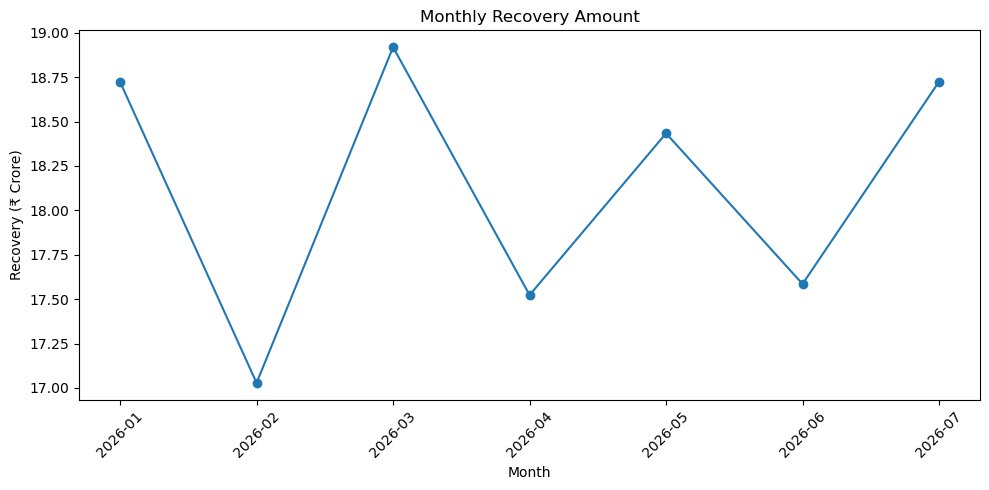

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(complete_months["month"], complete_months["recovery_amount"] / 1e7, marker="o")
plt.title("Monthly Recovery Amount")
plt.xlabel("Month")
plt.ylabel("Recovery (₹ Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What I found 

There is no 11% month on month improvement.Only March shows approximately +11.1% versus February, but the other months include declines and small increases.

In [39]:
segment_analysis = golden_account_month[golden_account_month["target_count"] > 0].copy()

risk_summary = segment_analysis.groupby("risk_segment").agg(
    account_months=("account_id", "size"),
    recovered_accounts=("recovered_flag", "sum"),
    recovery_rate=("recovered_flag", "mean"),
    recovery_amount=("recovery_amount", "sum"),
    recovery_per_account=("recovery_amount", "mean")
).reset_index().sort_values("recovery_rate", ascending=False)

risk_summary

,risk_segment,account_months,recovered_accounts,recovery_rate,recovery_amount,recovery_per_account
1,LOW,10301,815.00,0.08,"64,261,419.91","6,238.37"
0,HIGH,10129,799.00,0.08,"62,408,792.79","6,161.40"
2,MEDIUM,10272,771.00,0.08,"61,094,999.13","5,947.72"
3,NPA,10008,722.00,0.07,"55,731,338.59","5,568.68"


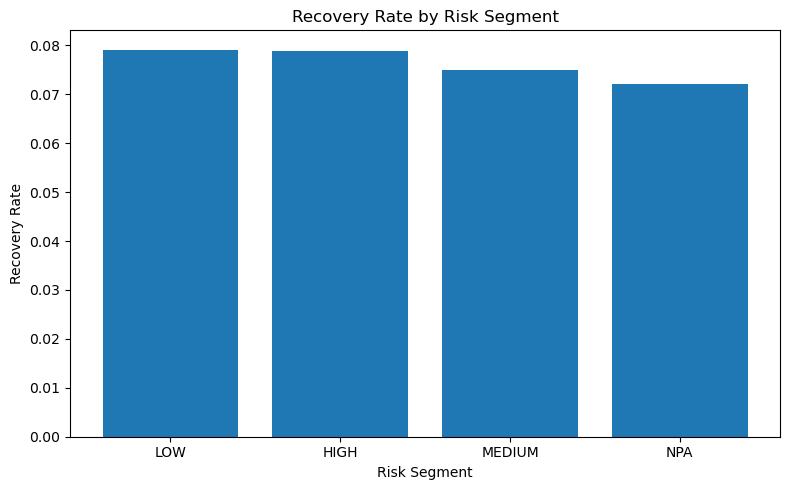

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(risk_summary["risk_segment"].astype(str), risk_summary["recovery_rate"])
plt.title("Recovery Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Recovery Rate")
plt.tight_layout()
plt.show()

In [41]:
loan_summary = segment_analysis.groupby("loan_type").agg(
    account_months=("account_id", "size"),
    recovery_rate=("recovered_flag", "mean"),
    recovery_amount=("recovery_amount", "sum"),
    recovery_per_account=("recovery_amount", "mean")
).reset_index().sort_values("recovery_rate", ascending=False)

loan_summary

,loan_type,account_months,recovery_rate,recovery_amount,recovery_per_account
2,CONSUMER,8038,0.08,"48,992,272.58","6,095.08"
0,AUTO,8272,0.08,"51,641,861.79","6,242.97"
3,CREDIT_CARD,8251,0.08,"48,718,451.70","5,904.55"
4,PERSONAL,8100,0.07,"45,666,782.18","5,637.87"
1,BNPL,8049,0.07,"48,477,182.17","6,022.76"


In [42]:
dpd_summary = segment_analysis.groupby("dpd_bucket", observed=False).agg(
    account_months=("account_id", "size"),
    recovery_rate=("recovered_flag", "mean"),
    recovery_amount=("recovery_amount", "sum"),
    recovery_per_account=("recovery_amount", "mean")
).reset_index()

dpd_summary

,dpd_bucket,account_months,recovery_rate,recovery_amount,recovery_per_account
0,0-30,18360,0.07,"106,275,040.62","5,788.40"
1,31-60,7614,0.08,"48,210,851.60","6,331.87"
2,61-90,7356,0.08,"45,504,780.69","6,186.08"
3,91-180,7380,0.08,"43,505,877.51","5,895.11"
4,180+,0,NaN,0.00,NaN


In [43]:
channel_summary = segment_analysis.groupby("recommended_channel").agg(
    account_months=("account_id", "size"),
    recovered_accounts=("recovered_flag", "sum"),
    recovery_rate=("recovered_flag", "mean"),
    recovery_amount=("recovery_amount", "sum"),
    recovery_per_account=("recovery_amount", "mean")
).reset_index().sort_values("recovery_rate", ascending=False)

channel_summary

,recommended_channel,account_months,recovered_accounts,recovery_rate,recovery_amount,recovery_per_account
1,SMS,10150,820.00,0.08,"65,450,630.82","6,448.34"
0,FIELD,10290,793.00,0.08,"60,615,040.50","5,890.67"
2,VOICE,10116,753.00,0.07,"58,720,709.89","5,804.74"
3,WHATSAPP,10154,741.00,0.07,"58,710,169.21","5,781.97"


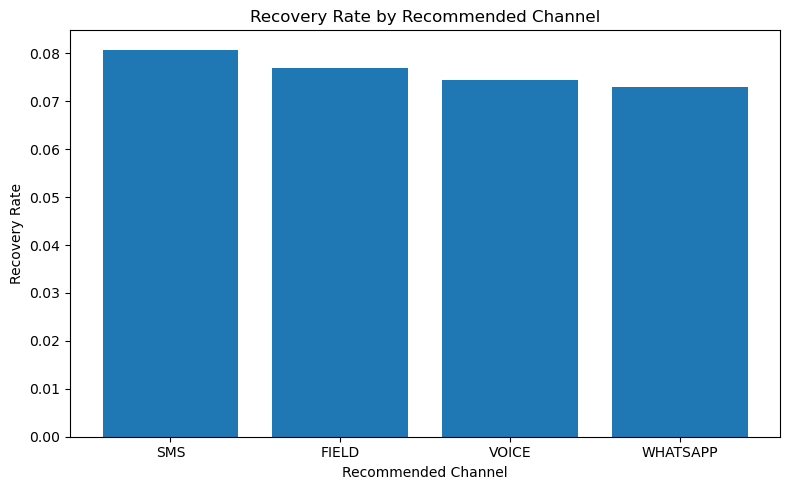

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(channel_summary["recommended_channel"].astype(str), channel_summary["recovery_rate"])
plt.title("Recovery Rate by Recommended Channel")
plt.xlabel("Recommended Channel")
plt.ylabel("Recovery Rate")
plt.tight_layout()
plt.show()

In [45]:
priority_summary = segment_analysis.groupby("priority").agg(
    account_months=("account_id", "size"),
    recovery_rate=("recovered_flag", "mean"),
    recovery_amount=("recovery_amount", "sum"),
    recovery_per_account=("recovery_amount", "mean")
).reset_index()

priority_summary

,priority,account_months,recovery_rate,recovery_amount,recovery_per_account
0,1.00,4134,0.08,"26,706,657.59","6,460.25"
1,2.00,4093,0.07,"23,507,834.46","5,743.42"
2,3.00,4082,0.07,"23,352,069.60","5,720.74"
3,4.00,3975,0.07,"23,195,281.10","5,835.29"
4,5.00,3989,0.08,"24,285,298.38","6,088.07"
5,6.00,4003,0.08,"24,763,675.61","6,186.28"
6,7.00,4169,0.07,"24,079,185.37","5,775.77"
7,8.00,4130,0.08,"26,590,403.20","6,438.35"
8,9.00,4127,0.07,"23,649,342.97","5,730.40"
9,10.00,4008,0.08,"23,366,802.14","5,830.04"


In [46]:
monthly_metrics[[
    "month", "contact_rate", "rpc_rate", "targeted_recovery_rate",
    "ptp_count", "ptp_kept_rate", "recovery_per_targeted_account"
]]

,month,contact_rate,rpc_rate,targeted_recovery_rate,ptp_count,ptp_kept_rate,recovery_per_targeted_account
0,2026-01,0.20,0.30,0.41,"2,522.00",0.32,"32,663.84"
1,2026-02,0.20,0.30,0.42,"2,220.00",0.34,"32,999.93"
2,2026-03,0.20,0.30,0.43,"2,509.00",0.33,"33,390.46"
3,2026-04,0.19,0.30,0.41,"2,492.00",0.33,"31,374.92"
4,2026-05,0.20,0.30,0.40,"2,507.00",0.33,"31,781.98"
5,2026-06,0.20,0.30,0.41,"2,439.00",0.33,"31,771.17"
6,2026-07,0.19,0.29,0.41,"2,626.00",0.33,"33,047.62"
7,2026-08,0.20,0.31,0.39,685.00,0.35,"30,082.82"


In [47]:
agent_sessions_clean = agent_sessions.copy()
agent_sessions_clean["login_at"] = pd.to_datetime(agent_sessions_clean["login_at"])
agent_sessions_clean["logout_at"] = pd.to_datetime(agent_sessions_clean["logout_at"])
agent_sessions_clean["session_hours"] = (
    agent_sessions_clean["logout_at"] - agent_sessions_clean["login_at"]
).dt.total_seconds() / 3600

agent_hours = agent_sessions_clean.groupby("agent_id").agg(
    session_count=("session_id", "nunique"),
    total_hours=("session_hours", "sum")
).reset_index()

agent_hours.head()

,agent_id,session_count,total_hours
0,AGT0000001,18,87.04
1,AGT0000002,16,65.22
2,AGT0000003,13,68.86
3,AGT0000004,11,61.59
4,AGT0000005,14,90.30


In [48]:
vendor_call_summary = calls_clean.groupby("vendor_id").agg(
    calls=("call_id", "nunique"),
    answered=("call_status", lambda x: (x == "ANSWERED").sum()),
    avg_duration=("duration_sec", "mean")
).reset_index()

vendor_call_summary["contact_rate"] = vendor_call_summary["answered"] / vendor_call_summary["calls"]
vendor_call_summary.sort_values("contact_rate", ascending=False)

,vendor_id,calls,answered,avg_duration,contact_rate
13,VND0000014,6040,1274,452.53,0.21
5,VND0000006,5896,1227,450.84,0.21
9,VND0000010,6163,1251,453.73,0.20
12,VND0000013,5902,1188,453.42,0.20
10,VND0000011,6070,1220,450.92,0.20
2,VND0000003,5964,1188,454.37,0.20
7,VND0000008,5911,1168,448.87,0.20
14,VND0000015,6065,1193,454.77,0.20
1,VND0000002,5933,1167,443.25,0.20
3,VND0000004,5925,1156,450.57,0.20


In [49]:
hour_summary = calls_clean.groupby("hour_ist").agg(
    calls=("call_id", "nunique"),
    answered=("call_status", lambda x: (x == "ANSWERED").sum())
).reset_index()

hour_summary["contact_rate"] = hour_summary["answered"] / hour_summary["calls"]
hour_summary

,hour_ist,calls,answered,contact_rate
0,0,3752,760,0.20
1,1,3731,765,0.21
2,2,3806,718,0.19
3,3,3704,725,0.20
4,4,3732,767,0.21
5,5,3903,762,0.20
6,6,3677,699,0.19
7,7,3799,735,0.19
8,8,3836,758,0.20
9,9,3619,728,0.20


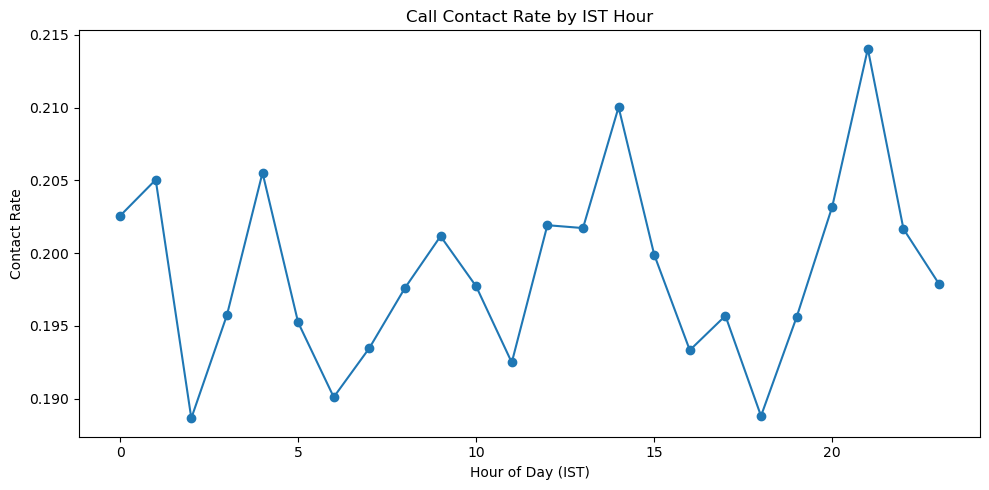

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(hour_summary["hour_ist"], hour_summary["contact_rate"], marker="o")
plt.title("Call Contact Rate by IST Hour")
plt.xlabel("Hour of Day (IST)")
plt.ylabel("Contact Rate")
plt.tight_layout()
plt.show()

In [51]:
min_target_date = daily_targeting_clean["target_date"].min()
max_target_date = daily_targeting_clean["target_date"].max()
midpoint = min_target_date + (max_target_date - min_target_date) / 2

print("Targeting period:", min_target_date.date(), "to", max_target_date.date())
print("Midpoint:", midpoint)

# Use complete months before and after the midpoint to avoid mixing April and partial August.
before_months = ["2026-01", "2026-02", "2026-03"]
after_months = ["2026-05", "2026-06", "2026-07"]

before = segment_analysis[segment_analysis["month"].isin(before_months)]
after = segment_analysis[segment_analysis["month"].isin(after_months)]

strategy_summary = pd.DataFrame({
    "period": ["Before", "After"],
    "account_months": [len(before), len(after)],
    "recovery_rate": [before["recovered_flag"].mean(), after["recovered_flag"].mean()],
    "recovery_amount": [before["recovery_amount"].sum(), after["recovery_amount"].sum()],
    "recovery_per_account_month": [before["recovery_amount"].mean(), after["recovery_amount"].mean()]
})

strategy_summary

Targeting period: 2026-01-01 to 2026-08-08
Midpoint: 2026-04-20 12:00:00


,period,account_months,recovery_rate,recovery_amount,recovery_per_account_month
0,Before,16558,0.08,"103,673,065.89","6,261.21"
1,After,17001,0.08,"105,038,423.21","6,178.37"


In [52]:
monthly_targeted_account_months = (
    segment_analysis[segment_analysis["month"] <= "2026-07"]
    .groupby("month")
    .size()
    .mean()
)

average_recovery_per_recovered_account = (
    segment_analysis[
        (segment_analysis["month"] <= "2026-07") &
        (segment_analysis["recovered_flag"] == 1)
    ]["recovery_amount"].mean()
)

investment = 100_000_000  # ₹10 crore

lifts = [0.005, 0.01, 0.02, 0.03]
scenario_rows = []

for lift in lifts:
    monthly_incremental_recovery = (
        monthly_targeted_account_months *
        lift *
        average_recovery_per_recovered_account
    )
    annual_incremental_recovery = monthly_incremental_recovery * 12
    roi = (annual_incremental_recovery - investment) / investment

    scenario_rows.append({
        "assumed_absolute_recovery_lift": lift,
        "annual_incremental_recovery": annual_incremental_recovery,
        "ROI": roi
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_table

,assumed_absolute_recovery_lift,annual_incremental_recovery,ROI
0,0.01,"26,312,782.16",-0.74
1,0.01,"52,625,564.31",-0.47
2,0.02,"105,251,128.62",0.05
3,0.03,"157,876,692.94",0.58


In [53]:
break_even_lift = investment / (
    monthly_targeted_account_months *
    average_recovery_per_recovered_account *
    12
)

print("Average monthly targeted account-months:", round(monthly_targeted_account_months))
print("Average recovery per recovered account-month: ₹", round(average_recovery_per_recovered_account))
print("Break-even absolute recovery-rate lift:", round(break_even_lift * 100, 2), "percentage points")

Average monthly targeted account-months: 5592
Average recovery per recovered account-month: ₹ 78424
Break-even absolute recovery-rate lift: 1.9 percentage points


### `01_clean_payments.sql`

```sql
-- Remove exact duplicate payment rows
CREATE TABLE clean_payments AS
SELECT DISTINCT *
FROM payments;

-- Successful payments are the recovery events
CREATE TABLE successful_payments AS
SELECT
    payment_id,
    account_id,
    event_at,
    amount
FROM clean_payments
WHERE payment_status = 'SUCCESS';
```

### `02_clean_calls.sql`

```sql
-- Remove exact duplicates first
WITH dedup AS (
    SELECT DISTINCT *
    FROM calls
),

-- Find call IDs with conflicting timestamps
conflicting_calls AS (
    SELECT call_id
    FROM dedup
    GROUP BY call_id
    HAVING COUNT(DISTINCT event_at) > 1
)

SELECT *
FROM dedup
WHERE call_id NOT IN (SELECT call_id FROM conflicting_calls);
```

### `03_account_month_metrics.sql`

```sql
-- Always aggregate event tables before joining them.

WITH payment_month AS (
    SELECT
        account_id,
        DATE_TRUNC('month', event_at) AS month,
        SUM(CASE WHEN payment_status = 'SUCCESS' THEN amount ELSE 0 END) AS recovery_amount
    FROM clean_payments
    GROUP BY account_id, DATE_TRUNC('month', event_at)
),

call_month AS (
    SELECT
        account_id,
        DATE_TRUNC('month', event_at) AS month,
        COUNT(DISTINCT call_id) AS call_count,
        SUM(CASE WHEN call_status = 'ANSWERED' THEN 1 ELSE 0 END) AS answered_calls
    FROM clean_calls
    GROUP BY account_id, DATE_TRUNC('month', event_at)
)

SELECT
    a.account_id,
    a.borrower_id,
    p.month,
    COALESCE(p.recovery_amount, 0) AS recovery_amount,
    COALESCE(c.call_count, 0) AS call_count,
    COALESCE(c.answered_calls, 0) AS answered_calls
FROM accounts a
LEFT JOIN payment_month p
    ON a.account_id = p.account_id
LEFT JOIN call_month c
    ON a.account_id = c.account_id
   AND p.month = c.month;
```

In [55]:
golden_account_month.to_csv("golden_account_month.csv", index=False)
monthly_metrics.to_csv("monthly_metrics.csv", index=False)
data_quality_impact.to_csv("data_quality_impact.csv", index=False)